# Actividad - Proyecto práctico

> Grupo 9 — **SpaceInvaders** | Objetivo: media de recompensa > 20 puntos (con reward clipping) en test.  
> Algoritmo: **DQN** y variantes.

*   Alumna 1: Paula Caro Miralles
*   Alumna 2: Celia Pérez Alonso


> Hemos optado por usar PyTorch en lugar de Keras/Tensorflow por varios motivos:
> - Incompatibilidades que no hemos logrado resolver en Google Colab
> - Compatibilidad con CUDA 12.8 en el entorno local de desarrollo
> - Mayor flexibilidad para implementar variantes de DQN desde cero

---
## **PARTE 1** - Enunciado

- **Entorno**: `SpaceInvaders-v0`
- **Algoritmo**: DQN (mínimo 3 propuestas de mejora)
- **Objetivo mínimo**: media de recompensa > **20 puntos** (con reward clipping) en 100 episodios de test
- **Entrega**: notebook + pesos del mejor modelo + vídeo de test en `.zip`

**Rúbrica**: Se valorará la originalidad de la solución y la discusión detallada de resultados.  
Se deben incluir al menos **3 gráficas** comparando las 3 propuestas.

---
## **PARTE 2** - Desarrollo

### 2.1. Importar librerías

In [1]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA disponible:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Usando:', device)

PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Usando: cuda


In [2]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import gymnasium as gym

# Reproducibilidad
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

---
### 2.2. Configuración base del entorno

In [3]:
INPUT_SHAPE   = (84, 84)
WINDOW_LENGTH = 4   # frames apilados

import ale_py
gym.register_envs(ale_py)
env_name = 'SpaceInvaders-v0'
env = gym.make(env_name)
nb_actions = env.action_space.n

print('Entorno:',  env_name)
print('Acciones:', nb_actions)
print('Observación:', env.observation_space)

Entorno: SpaceInvaders-v0
Acciones: 6
Observación: Box(0, 255, (210, 160, 3), uint8)


/home/paulacaro/miniconda3/envs/tfm_gnn/lib/python3.11/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment SpaceInvaders-v0 is out of date. You should consider upgrading to version `v4`.
  logger.deprecation(
A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[Powered by Stella]


---
### 2.3. Preprocesado, reward clipping y frame stacking

> **AtariProcessor**: convierte frames a escala de grises 84×84 y clipea la recompensa a [-1, 1].  
> **FrameStack**: mantiene una ventana deslizante de los últimos 4 frames como estado.

In [4]:
class AtariProcessor:
    """Preprocesa observaciones y clipea recompensas"""

    def process_observation(self, obs):
        img = Image.fromarray(obs).resize(INPUT_SHAPE).convert('L')
        return np.array(img, dtype=np.uint8)

    def process_reward(self, reward):
        return np.clip(reward, -1., 1.)


class FrameStack:
    """Apila los últimos k frames como estado."""

    def __init__(self, k=4):
        self.k = k
        self.frames = deque(maxlen=k)

    def reset(self, frame):
        for _ in range(self.k):
            self.frames.append(frame)
        return np.array(self.frames, dtype=np.uint8)

    def step(self, frame):
        self.frames.append(frame)
        return np.array(self.frames, dtype=np.uint8)

---
#### 2.3.1. Pipeline de preprocesado mejorado (`AtariEnvV0`)

Construido **sobre** `AtariProcessor` y `FrameStack`, añade las técnicas estándar de Atari compatibles con v0:

- **Frame-max**: máximo de las 2 últimas observaciones. Los sprites de *SpaceInvaders* (láseres, aliens) parpadean
  en frames alternos; sin esto el agente "pierde" objetos.
- **Noop-reset**: 1–30 no-ops al empezar cada partida → estados iniciales diversos.
- **Episodic-life**: perder una vida cuenta como fin de episodio **solo para el aprendizaje** (bootstrapping), sin
  reiniciar la partida real. Mejora la asignación de crédito en juegos con vidas.

In [5]:
class AtariEnvV0:
    '''Envuelve SpaceInvaders-v0 con el preprocesado estandar de Atari,
    construido sobre el AtariProcessor y el FrameStack ya definidos:
      - frame-max: max de las 2 ultimas observaciones (los sprites de SpaceInvaders parpadean)
      - noop-reset: 1..noop_max no-ops al empezar la partida (arranques diversos)
      - episodic-life: perder una vida = fin de episodio solo para el aprendizaje (bootstrapping),
        sin reiniciar la partida real.'''
    def __init__(self, env_name, noop_max=30, episodic_life=True, frame_max=True, seed=None):
        self.env = gym.make(env_name)
        self.processor = AtariProcessor()
        self.noop_max = noop_max
        self.episodic_life = episodic_life
        self.frame_max = frame_max
        self.seed = seed
        self.lives = 0
        self.real_done = True
        self._last2 = deque(maxlen=2)
        self._seeded = False

    def _obs(self, raw):
        frame = self.processor.process_observation(raw)
        if not self.frame_max:
            return frame
        self._last2.append(frame)
        return np.max(np.stack(list(self._last2)), axis=0).astype(np.uint8)

    def reset(self):
        if self.real_done:
            if (not self._seeded) and (self.seed is not None):
                obs, info = self.env.reset(seed=self.seed); self._seeded = True
            else:
                obs, info = self.env.reset()
            for _ in range(np.random.randint(1, self.noop_max + 1)):
                obs, _, term, trunc, info = self.env.step(0)          # 0 = NOOP
                if term or trunc:
                    obs, info = self.env.reset()
            self.lives = info.get('lives', 0)
            self.real_done = False
        else:
            obs, _, term, trunc, info = self.env.step(0)              # continua la partida (sin reset real)
            self.real_done = term or trunc
            self.lives = info.get('lives', self.lives)
        self._last2.clear()
        return self._obs(obs)

    def step(self, action):
        obs, reward, term, trunc, info = self.env.step(action)
        self.real_done = term or trunc
        lives = info.get('lives', self.lives)
        done = self.real_done
        if self.episodic_life and (0 < lives < self.lives):
            done = True
        self.lives = lives
        return self._obs(obs), reward, done, self.real_done, info

    def close(self):
        self.env.close()


def clip_reward(reward):
    '''Reward clipping [-1, 1]: cada adversario eliminado = +1 (no los puntos del juego).'''
    return float(np.clip(reward, -1.0, 1.0))

---
### 2.4. Replay Buffer

> Almacena experiencias (s, a, r, s', done) para el entrenamiento offline.  
> Los estados se guardan como uint8 para reducir uso de memoria.

In [6]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states,      dtype=np.uint8),
            np.array(actions,     dtype=np.int64),
            np.array(rewards,     dtype=np.float32),
            np.array(next_states, dtype=np.uint8),
            np.array(dones,       dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)

---
### 2.5. Implementación de la red neuronal

> Dos arquitecturas:  
> - `NatureDQN`: CNN estándar — usada en Baseline (Mnih et al. (2015)) y Double DQN (van Hasselt et al. (2016))
> - `DuelingDQN`: misma CNN pero con cabeza separada Value + Advantage (Wang et al. (2016))

In [7]:
class NatureDQN(nn.Module):
    """
    Nature DQN.
    Entrada: (batch, 4, 84, 84) — 4 frames apilados en escala de grises.
    Salida:  (batch, nb_actions) — Q-value por acción.
    """
    def __init__(self, nb_actions, window_length=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(window_length, 32, kernel_size=8, stride=4),  # (32, 20, 20)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),             # (64,  9,  9)
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),             # (64,  7,  7)
            nn.ReLU(),
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, nb_actions),
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class DuelingDQN(nn.Module):
    """
    Dueling DQN.
    Misma CNN pero la cabeza se divide en:
      - V(s):    valor del estado (escalar)
      - A(s,a):  ventaja por acción
    Q(s,a) = V(s) + A(s,a) - mean(A(s,.))
    """
    def __init__(self, nb_actions, window_length=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(window_length, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )
        self.fc_shared = nn.Linear(64 * 7 * 7, 512)
        # Stream de valor
        self.value_stream = nn.Linear(512, 1)
        # Stream de ventaja
        self.advantage_stream = nn.Linear(512, nb_actions)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc_shared(x))
        value     = self.value_stream(x)
        advantage = self.advantage_stream(x)
        # Combinación por media (recomendada en el paper)
        q = value + advantage - advantage.mean(dim=1, keepdim=True)
        return q


# Verificamos arquitecturas
test_input = torch.zeros(1, WINDOW_LENGTH, *INPUT_SHAPE)
print('NatureDQN output: ', NatureDQN(nb_actions).forward(test_input).shape)
print('DuelingDQN output:', DuelingDQN(nb_actions).forward(test_input).shape)

NatureDQN output:  torch.Size([1, 6])
DuelingDQN output: torch.Size([1, 6])


---
### 2.6. Funciones de entrenamiento y test

> Loop de entrenamiento DQN unificado. El parámetro `double_dqn` activa Double DQN.

In [8]:
def update_dqn(online_net, target_net, optimizer, replay_buffer, config, double_dqn):
    """Un paso de actualización de los pesos de la red."""
    states, actions, rewards, next_states, dones = replay_buffer.sample(config['BATCH_SIZE'])

    # Normalizar a [0, 1] y mover a GPU
    states      = torch.FloatTensor(states).to(device)      / 255.0
    next_states = torch.FloatTensor(next_states).to(device) / 255.0
    actions     = torch.LongTensor(actions).to(device)
    rewards     = torch.FloatTensor(rewards).to(device)
    dones       = torch.FloatTensor(dones).to(device)

    # Q-values actuales
    current_q = online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    # Q-values objetivo
    with torch.no_grad():
        if double_dqn:
            # Double DQN: online selecciona, target evalúa
            next_actions = online_net(next_states).argmax(1)
            next_q = target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze(1)
        else:
            # DQN estándar
            next_q = target_net(next_states).max(1)[0]

        target_q = rewards + config['GAMMA'] * next_q * (1 - dones)

    loss = F.smooth_l1_loss(current_q, target_q)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(online_net.parameters(), 10)
    optimizer.step()

    return loss.item()

In [9]:
import time

def evaluate(net, nb_episodes=100, eps=0.0):
    '''
        Evalua en episodios completos (todas las vidas) acumulando la recompensa clipada [-1,1].
        Devuelve (clip, raw).
    '''
    env = AtariEnvV0(env_name, episodic_life=False)      # partidas completas
    frame_stack = FrameStack(WINDOW_LENGTH)
    net.eval()
    clipped, raw = [], []
    for _ in range(nb_episodes):
        state = frame_stack.reset(env.reset())
        cr, rr, done = 0.0, 0.0, False
        while not done:
            if random.random() < eps:
                action = random.randrange(nb_actions)
            else:
                with torch.no_grad():
                    s = torch.FloatTensor(state).unsqueeze(0).to(device) / 255.0
                    action = net(s).argmax().item()
            obs, reward, _, real_done, _ = env.step(action)
            done = real_done
            cr += clip_reward(reward); rr += reward
            state = frame_stack.step(obs)
        clipped.append(cr); raw.append(rr)
    env.close(); net.train()
    return np.array(clipped), np.array(raw)


def quick_eval(net, n=30):
    c, _ = evaluate(net, n, eps=0.0)
    return float(c.mean())


def test_agent(net, nb_episodes=100, eps=0.0, verbose=True):
    '''Evalua y muestra el resultado con reward clipping.'''
    clipped, raw = evaluate(net, nb_episodes, eps)
    if verbose:
        for i, (c, r) in enumerate(zip(clipped, raw)):
            print(f'  Episodio {i+1}: reward(clip) = {c:.0f} | raw = {r:.0f}')
    m = clipped.mean()
    print(f'\nMedia CLIPADA: {m:.2f} | Std: {clipped.std():.2f}  (raw ref: {raw.mean():.0f})')
    return [float(x) for x in clipped]


def save_log(episode_rewards, losses, path):
    '''Guarda logs en formato compatible con las graficas.'''
    with open(path, 'w') as f:
        json.dump({'episode_reward': episode_rewards, 'loss': losses}, f)
    print(f'Log guardado: {path}')


def train_dqn(online_net, target_net, optimizer, config, double_dqn=False, label=''):
    '''Loop de entrenamiento DQN con pipeline mejorado:
       - preprocesado AtariEnvV0 (frame-max, noop-reset, episodic-life)
       - recompensa CLIPADA en el buffer y en la curva de episodios (por partida completa)
       - checkpointing por evaluacion: guarda el MEJOR modelo en dqn_{label}.pt
       Devuelve (episode_rewards, losses), con episode_rewards en escala clipada.'''
    env_train = AtariEnvV0(env_name, episodic_life=True, seed=SEED)
    frame_stack = FrameStack(WINDOW_LENGTH)
    replay_buffer = ReplayBuffer(config['MEMORY_LIMIT'])

    online_net.train()
    target_net.load_state_dict(online_net.state_dict())
    target_net.eval()

    episode_rewards, losses, eval_history = [], [], []
    episode_reward = 0.0
    best, best_step = -1.0, None

    state = frame_stack.reset(env_train.reset())
    t0 = time.time()

    for step in range(1, config['NB_STEPS'] + 1):
        eps = max(config['EPS_MIN'],
                  config['EPS_MAX'] - (config['EPS_MAX'] - config['EPS_MIN']) * step / config['EPS_STEPS'])

        if step < config['NB_STEPS_WARMUP'] or random.random() < eps:
            action = random.randrange(nb_actions)
        else:
            with torch.no_grad():
                s = torch.FloatTensor(state).unsqueeze(0).to(device) / 255.0
                action = online_net(s).argmax().item()

        next_obs, reward, done, real_done, _ = env_train.step(action)
        clipped_reward = clip_reward(reward)
        next_state = frame_stack.step(next_obs)
        replay_buffer.push(state, action, clipped_reward, next_state, float(done))
        state = next_state
        episode_reward += clipped_reward

        if done:
            state = frame_stack.reset(env_train.reset())
            if real_done:                                  # solo se cierra el episodio al perder la partida
                episode_rewards.append(episode_reward)
                episode_reward = 0.0

        if step >= config['NB_STEPS_WARMUP'] and step % config['TRAIN_INTERVAL'] == 0 and len(replay_buffer) >= config['BATCH_SIZE']:
            losses.append(update_dqn(online_net, target_net, optimizer, replay_buffer, config, double_dqn))

        if step % config['TARGET_UPDATE'] == 0:
            target_net.load_state_dict(online_net.state_dict())

        if step % config['EVAL_EVERY'] == 0:
            m = quick_eval(online_net, config['EVAL_EPISODES'])
            eval_history.append((step, m))
            flag = ''
            if m > best:
                best, best_step = m, step
                torch.save(online_net.state_dict(), f'dqn_{label}.pt'); flag = '  <-- MEJOR (guardado)'
            mean_r = np.mean(episode_rewards[-50:]) if episode_rewards else 0
            print(f'[{label}] Step {step:>7}/{config["NB_STEPS"]} | eps {eps:.3f} | '
                  f'Media clip ult.50 ep: {mean_r:5.1f} | eval greedy {m:5.2f} | best {best:5.2f}{flag} | {(time.time()-t0)/60:.0f} min')
        elif step % 10_000 == 0:
            mean_r = np.mean(episode_rewards[-50:]) if episode_rewards else 0
            print(f'[{label}] Step {step:>7}/{config["NB_STEPS"]} | eps {eps:.3f} | '
                  f'Media clip ult.50 ep: {mean_r:5.1f} | Episodios: {len(episode_rewards)}')

    env_train.close()
    if best_step is None:                                  # entrenamientos muy cortos sin evaluacion
        torch.save(online_net.state_dict(), f'dqn_{label}.pt')
    print(f'\n[{label}] Fin. Mejor eval greedy = {best:.2f} @ step {best_step}  ->  dqn_{label}.pt')
    return episode_rewards, losses

---
### 2.7. Hiperparámetros

> Fase 1: mismo presupuesto (1M pasos) para las tres arquitecturas.

| Hiperparámetro | Valor | Descripción |
|---|---|---|
| `NB_STEPS` | 1.000.000 (Fase 1) / 3.000.000 (Fase 2) | Pasos de entrenamiento |
| `NB_STEPS_WARMUP` | 50.000 | Pasos aleatorios antes de aprender |
| `BATCH_SIZE` | 32 | Muestras por actualización |
| `GAMMA` | 0.99 | Factor de descuento |
| `TARGET_UPDATE` | 10.000 | Frecuencia de actualización de la red objetivo |
| `TRAIN_INTERVAL` | 4 | Cada cuántos pasos se actualiza la red |
| `LEARNING_RATE` | 0.0001 | Bajado desde 2.5e-4 para estabilidad (evita el colapso al escalar pasos) |
| `MEMORY_LIMIT` | 150.000 | Ajustado a la RAM (subir a 200.000 si es posible) |
| `EPS_MAX → EPS_MIN` | 1.0 → 0.05 | Decaimiento lineal de exploración |
| `EVAL_EVERY / EVAL_EPISODES` | 100.000 / 30 | Evaluación periódica + guardado del mejor modelo |

In [10]:
CONFIG = {
    'NB_STEPS':        1_000_000,   # Fase 1: mismo presupuesto para las 3 arquitecturas
    'NB_STEPS_WARMUP': 50_000,
    'BATCH_SIZE':      32,
    'GAMMA':           0.99,
    'TARGET_UPDATE':   10_000,
    'TRAIN_INTERVAL':  4,
    'LEARNING_RATE':   1e-4,        # estable (evita el colapso al escalar pasos)
    'MEMORY_LIMIT':    150_000,     
    'EPS_MAX':         1.0,
    'EPS_MIN':         0.05,
    'EPS_STEPS':       1_000_000,
    'EVAL_EVERY':      100_000,     # evaluar y guardar el mejor cada 100k pasos
    'EVAL_EPISODES':   30,
}

# Fase 2: misma configuracion escalando los pasos para la arquitectura ganadora
CONFIG_3M = dict(CONFIG); CONFIG_3M['NB_STEPS'] = 3_000_000

---
## **FASE 1 — Comparación de arquitecturas** (1M pasos, mismo pipeline)

Se entrenan las tres propuestas con idéntico presupuesto y pipeline para elegir la mejor de forma justa. Cada celda
de entrenamiento **carga los pesos/logs guardados si existen**, para no reentrenar al reiniciar la sesión.

---
### 2.8. **Propuesta 1:** DQN Baseline

> DQN estándar (Mnih et al., 2015). Red online + red objetivo fija.
> La red objetivo se copia de la online cada 10.000 pasos.

In [34]:
online_baseline = NatureDQN(nb_actions).to(device)
target_baseline = NatureDQN(nb_actions).to(device)
optimizer_baseline = optim.Adam(online_baseline.parameters(), lr=CONFIG['LEARNING_RATE'])

total_params = sum(p.numel() for p in online_baseline.parameters())
print(f'Parámetros del modelo: {total_params:,}')

Parámetros del modelo: 1,687,206


In [35]:
if os.path.exists('dqn_baseline_pipe.pt') and os.path.exists('baseline_pipe_log.json'):
    print('[baseline_pipe] Pesos y log encontrados: se cargan (sin reentrenar).')
    online_baseline.load_state_dict(torch.load('dqn_baseline_pipe.pt', map_location=device))
    with open('baseline_pipe_log.json') as f:
        _d = json.load(f)
    rewards_baseline, losses_baseline = _d['episode_reward'], _d['loss']
else:
    rewards_baseline, losses_baseline = train_dqn(
        online_baseline, target_baseline, optimizer_baseline,
        CONFIG, double_dqn=False, label='baseline_pipe'
    )
    save_log(rewards_baseline, losses_baseline, 'baseline_pipe_log.json')
    print('✓ Propuesta 1 completada')

[baseline_pipe] Step   10000/1000000 | eps 0.991 | Media clip ult.50 ep:   9.1 | Episodios: 13
[baseline_pipe] Step   20000/1000000 | eps 0.981 | Media clip ult.50 ep:   9.7 | Episodios: 27
[baseline_pipe] Step   30000/1000000 | eps 0.972 | Media clip ult.50 ep:   8.6 | Episodios: 44
[baseline_pipe] Step   40000/1000000 | eps 0.962 | Media clip ult.50 ep:   8.8 | Episodios: 57
[baseline_pipe] Step   50000/1000000 | eps 0.953 | Media clip ult.50 ep:   9.4 | Episodios: 71
[baseline_pipe] Step   60000/1000000 | eps 0.943 | Media clip ult.50 ep:   9.3 | Episodios: 85
[baseline_pipe] Step   70000/1000000 | eps 0.933 | Media clip ult.50 ep:   9.5 | Episodios: 101
[baseline_pipe] Step   80000/1000000 | eps 0.924 | Media clip ult.50 ep:   9.0 | Episodios: 116
[baseline_pipe] Step   90000/1000000 | eps 0.914 | Media clip ult.50 ep:   9.4 | Episodios: 129
[baseline_pipe] Step  100000/1000000 | eps 0.905 | Media clip ult.50 ep:   9.5 | eval greedy 13.13 | best 13.13  <-- MEJOR (guardado) | 4 min


In [40]:
if os.path.exists('results_baseline_pipe.json'):
    results_baseline = json.load(open('results_baseline_pipe.json'))
    test_rewards_baseline = results_baseline['test_rewards']
    print('Cargado results_baseline_pipe.json')
else:
    online_baseline.load_state_dict(torch.load('dqn_baseline_pipe.pt', map_location=device))
    test_rewards_baseline = test_agent(online_baseline, nb_episodes=100, eps=0.0, verbose=True)
    results_baseline = {'label': 'DQN Baseline', 'episode_reward': rewards_baseline,
                        'loss': losses_baseline, 'test_rewards': test_rewards_baseline,
                        'mean': float(np.mean(test_rewards_baseline)), 'std': float(np.std(test_rewards_baseline))}
    json.dump(results_baseline, open('results_baseline_pipe.json', 'w'), indent=2)

_mb = float(np.mean(test_rewards_baseline))
print('=' * 55)
print('  PROPUESTA 1 - DQN Baseline (1M, pipeline mejorado)')
print(f'  Media test (clip): {_mb:.2f}  ->  ' + ('OBJETIVO >20' if _mb > 20 else 'por debajo de 20'))
print('=' * 55)

/home/paulacaro/miniconda3/envs/tfm_gnn/lib/python3.11/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment SpaceInvaders-v0 is out of date. You should consider upgrading to version `v4`.
  logger.deprecation(


  Episodio 1: reward(clip) = 21 | raw = 310
  Episodio 2: reward(clip) = 18 | raw = 435
  Episodio 3: reward(clip) = 20 | raw = 285
  Episodio 4: reward(clip) = 21 | raw = 315
  Episodio 5: reward(clip) = 16 | raw = 215
  Episodio 6: reward(clip) = 24 | raw = 365
  Episodio 7: reward(clip) = 32 | raw = 525
  Episodio 8: reward(clip) = 18 | raw = 250
  Episodio 9: reward(clip) = 21 | raw = 300
  Episodio 10: reward(clip) = 21 | raw = 330
  Episodio 11: reward(clip) = 17 | raw = 240
  Episodio 12: reward(clip) = 25 | raw = 340
  Episodio 13: reward(clip) = 21 | raw = 320
  Episodio 14: reward(clip) = 19 | raw = 270
  Episodio 15: reward(clip) = 10 | raw = 155
  Episodio 16: reward(clip) = 30 | raw = 475
  Episodio 17: reward(clip) = 16 | raw = 195
  Episodio 18: reward(clip) = 11 | raw = 170
  Episodio 19: reward(clip) = 18 | raw = 230
  Episodio 20: reward(clip) = 23 | raw = 305
  Episodio 21: reward(clip) = 16 | raw = 190
  Episodio 22: reward(clip) = 30 | raw = 470
  Episodio 23: rewa

---
### 2.9. **Propuesta 2:** Double DQN

> **Mejora**: Double DQN (van Hasselt et al., 2016).  
> Desacopla selección y evaluación de acciones para reducir sobreestimación de Q-values:
> - La **red online** selecciona `argmax_a Q(s', a)`
> - La **red objetivo** evalúa `Q_target(s', a*)`
>
> Implementado en `update_dqn()` con `double_dqn=True`.

In [41]:
online_double = NatureDQN(nb_actions).to(device)
target_double = NatureDQN(nb_actions).to(device)
optimizer_double = optim.Adam(online_double.parameters(), lr=CONFIG['LEARNING_RATE'])

In [42]:
if os.path.exists('dqn_double_pipe.pt') and os.path.exists('double_pipe_log.json'):
    print('[double_pipe] Pesos y log encontrados: se cargan (sin reentrenar).')
    online_double.load_state_dict(torch.load('dqn_double_pipe.pt', map_location=device))
    with open('double_pipe_log.json') as f:
        _d = json.load(f)
    rewards_double, losses_double = _d['episode_reward'], _d['loss']
else:
    rewards_double, losses_double = train_dqn(
        online_double, target_double, optimizer_double,
        CONFIG, double_dqn=True, label='double_pipe'
    )
    save_log(rewards_double, losses_double, 'double_pipe_log.json')
    print('✓ Propuesta 2 completada')

[double_pipe] Step   10000/1000000 | eps 0.991 | Media clip ult.50 ep:   9.9 | Episodios: 15
[double_pipe] Step   20000/1000000 | eps 0.981 | Media clip ult.50 ep:   9.3 | Episodios: 28
[double_pipe] Step   30000/1000000 | eps 0.972 | Media clip ult.50 ep:   9.3 | Episodios: 43
[double_pipe] Step   40000/1000000 | eps 0.962 | Media clip ult.50 ep:   9.2 | Episodios: 57
[double_pipe] Step   50000/1000000 | eps 0.953 | Media clip ult.50 ep:   9.6 | Episodios: 72
[double_pipe] Step   60000/1000000 | eps 0.943 | Media clip ult.50 ep:   9.4 | Episodios: 88
[double_pipe] Step   70000/1000000 | eps 0.933 | Media clip ult.50 ep:   9.5 | Episodios: 104
[double_pipe] Step   80000/1000000 | eps 0.924 | Media clip ult.50 ep:   9.2 | Episodios: 120
[double_pipe] Step   90000/1000000 | eps 0.914 | Media clip ult.50 ep:   9.6 | Episodios: 134
[double_pipe] Step  100000/1000000 | eps 0.905 | Media clip ult.50 ep:   8.9 | eval greedy 10.90 | best 10.90  <-- MEJOR (guardado) | 3 min
[double_pipe] Step  

In [43]:
if os.path.exists('results_double_pipe.json'):
    results_double = json.load(open('results_double_pipe.json'))
    test_rewards_double = results_double['test_rewards']
    print('Cargado results_double_pipe.json')
else:
    online_double.load_state_dict(torch.load('dqn_double_pipe.pt', map_location=device))
    test_rewards_double = test_agent(online_double, nb_episodes=100, eps=0.0, verbose=True)
    results_double = {'label': 'Double DQN', 'episode_reward': rewards_double,
                      'loss': losses_double, 'test_rewards': test_rewards_double,
                      'mean': float(np.mean(test_rewards_double)), 'std': float(np.std(test_rewards_double))}
    json.dump(results_double, open('results_double_pipe.json', 'w'), indent=2)

_md_ = float(np.mean(test_rewards_double))
print('=' * 55)
print('  PROPUESTA 2 - Double DQN (1M, pipeline mejorado)')
print(f'  Media test (clip): {_md_:.2f}  ->  ' + ('OBJETIVO >20' if _md_ > 20 else 'por debajo de 20'))
print('=' * 55)

/home/paulacaro/miniconda3/envs/tfm_gnn/lib/python3.11/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment SpaceInvaders-v0 is out of date. You should consider upgrading to version `v4`.
  logger.deprecation(


  Episodio 1: reward(clip) = 25 | raw = 375
  Episodio 2: reward(clip) = 22 | raw = 325
  Episodio 3: reward(clip) = 24 | raw = 365
  Episodio 4: reward(clip) = 20 | raw = 275
  Episodio 5: reward(clip) = 29 | raw = 450
  Episodio 6: reward(clip) = 24 | raw = 365
  Episodio 7: reward(clip) = 19 | raw = 240
  Episodio 8: reward(clip) = 23 | raw = 345
  Episodio 9: reward(clip) = 15 | raw = 190
  Episodio 10: reward(clip) = 25 | raw = 425
  Episodio 11: reward(clip) = 16 | raw = 235
  Episodio 12: reward(clip) = 24 | raw = 370
  Episodio 13: reward(clip) = 23 | raw = 360
  Episodio 14: reward(clip) = 27 | raw = 405
  Episodio 15: reward(clip) = 27 | raw = 440
  Episodio 16: reward(clip) = 21 | raw = 315
  Episodio 17: reward(clip) = 25 | raw = 380
  Episodio 18: reward(clip) = 20 | raw = 285
  Episodio 19: reward(clip) = 19 | raw = 255
  Episodio 20: reward(clip) = 19 | raw = 265
  Episodio 21: reward(clip) = 21 | raw = 285
  Episodio 22: reward(clip) = 20 | raw = 445
  Episodio 23: rewa

---
### 2.10. **Propuesta 3:** Dueling Double DQN

> **Mejora**: Dueling Network Architecture (Wang et al., 2016) combinada con Double DQN.  
> La cabeza de la red se divide en dos streams:
> - **V(s)**: cuánto vale estar en el estado s
> - **A(s,a)**: ventaja relativa de cada acción
>
> Q(s,a) = V(s) + A(s,a) − mean(A(s,·))
>
> Especialmente útil en SpaceInvaders donde muchos frames no requieren acción específica.

In [44]:
online_dueling = DuelingDQN(nb_actions).to(device)
target_dueling = DuelingDQN(nb_actions).to(device)
optimizer_dueling = optim.Adam(online_dueling.parameters(), lr=CONFIG['LEARNING_RATE'])

In [45]:
if os.path.exists('dqn_dueling_pipe.pt') and os.path.exists('dueling_pipe_log.json'):
    print('[dueling_pipe] Pesos y log encontrados: se cargan (sin reentrenar).')
    online_dueling.load_state_dict(torch.load('dqn_dueling_pipe.pt', map_location=device))
    with open('dueling_pipe_log.json') as f:
        _d = json.load(f)
    rewards_dueling, losses_dueling = _d['episode_reward'], _d['loss']
else:
    rewards_dueling, losses_dueling = train_dqn(
        online_dueling, target_dueling, optimizer_dueling,
        CONFIG, double_dqn=True, label='dueling_pipe'   # Double + Dueling
    )
    save_log(rewards_dueling, losses_dueling, 'dueling_pipe_log.json')
    print('✓ Propuesta 3 completada')

[dueling_pipe] Step   10000/1000000 | eps 0.991 | Media clip ult.50 ep:   8.7 | Episodios: 15
[dueling_pipe] Step   20000/1000000 | eps 0.981 | Media clip ult.50 ep:   9.5 | Episodios: 30
[dueling_pipe] Step   30000/1000000 | eps 0.972 | Media clip ult.50 ep:   9.4 | Episodios: 45
[dueling_pipe] Step   40000/1000000 | eps 0.962 | Media clip ult.50 ep:   9.2 | Episodios: 59
[dueling_pipe] Step   50000/1000000 | eps 0.953 | Media clip ult.50 ep:   9.3 | Episodios: 73
[dueling_pipe] Step   60000/1000000 | eps 0.943 | Media clip ult.50 ep:   9.5 | Episodios: 88
[dueling_pipe] Step   70000/1000000 | eps 0.933 | Media clip ult.50 ep:   9.3 | Episodios: 103
[dueling_pipe] Step   80000/1000000 | eps 0.924 | Media clip ult.50 ep:   9.4 | Episodios: 118
[dueling_pipe] Step   90000/1000000 | eps 0.914 | Media clip ult.50 ep:   8.9 | Episodios: 134
[dueling_pipe] Step  100000/1000000 | eps 0.905 | Media clip ult.50 ep:   9.3 | eval greedy 10.10 | best 10.10  <-- MEJOR (guardado) | 3 min
[dueling_p

In [46]:
if os.path.exists('results_dueling_pipe.json'):
    results_dueling = json.load(open('results_dueling_pipe.json'))
    test_rewards_dueling = results_dueling['test_rewards']
    print('Cargado results_dueling_pipe.json')
else:
    online_dueling.load_state_dict(torch.load('dqn_dueling_pipe.pt', map_location=device))
    test_rewards_dueling = test_agent(online_dueling, nb_episodes=100, eps=0.0, verbose=True)
    results_dueling = {'label': 'Dueling Double DQN', 'episode_reward': rewards_dueling,
                       'loss': losses_dueling, 'test_rewards': test_rewards_dueling,
                       'mean': float(np.mean(test_rewards_dueling)), 'std': float(np.std(test_rewards_dueling))}
    json.dump(results_dueling, open('results_dueling_pipe.json', 'w'), indent=2)

_mu = float(np.mean(test_rewards_dueling))
print('=' * 55)
print('  PROPUESTA 3 - Dueling Double DQN (1M, pipeline mejorado)')
print(f'  Media test (clip): {_mu:.2f}  ->  ' + ('OBJETIVO >20' if _mu > 20 else 'por debajo de 20'))
print('=' * 55)

  Episodio 1: reward(clip) = 16 | raw = 190
  Episodio 2: reward(clip) = 16 | raw = 205
  Episodio 3: reward(clip) = 21 | raw = 270
  Episodio 4: reward(clip) = 28 | raw = 415
  Episodio 5: reward(clip) = 5 | raw = 45
  Episodio 6: reward(clip) = 9 | raw = 70
  Episodio 7: reward(clip) = 17 | raw = 210
  Episodio 8: reward(clip) = 15 | raw = 190
  Episodio 9: reward(clip) = 12 | raw = 125
  Episodio 10: reward(clip) = 25 | raw = 395
  Episodio 11: reward(clip) = 10 | raw = 110
  Episodio 12: reward(clip) = 22 | raw = 310
  Episodio 13: reward(clip) = 12 | raw = 125
  Episodio 14: reward(clip) = 12 | raw = 135
  Episodio 15: reward(clip) = 14 | raw = 185
  Episodio 16: reward(clip) = 16 | raw = 195
  Episodio 17: reward(clip) = 20 | raw = 250
  Episodio 18: reward(clip) = 16 | raw = 215
  Episodio 19: reward(clip) = 28 | raw = 425
  Episodio 20: reward(clip) = 18 | raw = 235
  Episodio 21: reward(clip) = 16 | raw = 185
  Episodio 22: reward(clip) = 16 | raw = 205
  Episodio 23: reward(c

---
### 2.11. **Comparación de la Fase 1**

La mejor arquitectura a igual presupuesto se escalará en la Fase 2.

In [47]:
print(f'{"Modelo":<24}{"media_clip":>12}{"std":>9}{"  >20?":>8}')
print('-' * 53)
_tab = [('DQN Baseline', test_rewards_baseline),
        ('Double DQN', test_rewards_double),
        ('Dueling Double DQN', test_rewards_dueling)]
for _name, _tr in _tab:
    _m, _s = float(np.mean(_tr)), float(np.std(_tr))
    print(f'{_name:<24}{_m:>12.2f}{_s:>9.2f}{("  si" if _m > 20 else "  no"):>8}')
_ganadora = max(_tab, key=lambda kv: np.mean(kv[1]))[0]
print('\nGanadora Fase 1:', _ganadora)

Modelo                    media_clip      std    >20?
-----------------------------------------------------
DQN Baseline                   21.77     5.50      si
Double DQN                     22.18     5.97      si
Dueling Double DQN             18.41     6.28      no

Ganadora Fase 1: Double DQN


---
## **FASE 2 — Escalar la arquitectura ganadora (Double DQN) a 3M pasos**

La Fase 1 muestra que **Double DQN** es la mejor a igual presupuesto. Se escala a 3M pasos con **checkpointing por evaluación**: aunque el final se degrade, `dqn_double3m_pipe.pt` guarda el mejor modelo evaluado. Así se consolida el margen sobre el objetivo de forma estable, sin el colapso que provocaba escalar pasos con la configuración inicial.

In [11]:
def finetune_dqn(online_net, target_net, optimizer, config, double_dqn, label,
                 eps_fixed=0.02, buffer_warmup=20_000):
    """Reanuda el entrenamiento desde los pesos ya cargados en online_net (no empieza de 0).
       Exploracion baja y constante, y checkpointing por evaluacion: guarda el mejor en dqn_{label}.pt.
       Imprime la media movil de 100 episodios (MA100)."""
    env_train = AtariEnvV0(env_name, episodic_life=True, seed=SEED)
    frame_stack = FrameStack(WINDOW_LENGTH)
    replay_buffer = ReplayBuffer(config['MEMORY_LIMIT'])

    online_net.train()
    target_net.load_state_dict(online_net.state_dict())
    target_net.eval()

    episode_rewards, losses = [], []
    episode_reward = 0.0
    best, best_step = -1.0, None
    state = frame_stack.reset(env_train.reset())
    t0 = time.time()

    for step in range(1, config['NB_STEPS'] + 1):
        if random.random() < eps_fixed:                       # exploracion BAJA y constante (no vuelve a 1.0)
            action = random.randrange(nb_actions)
        else:
            with torch.no_grad():
                s = torch.FloatTensor(state).unsqueeze(0).to(device) / 255.0
                action = online_net(s).argmax().item()

        next_obs, reward, done, real_done, _ = env_train.step(action)
        clipped_reward = clip_reward(reward)
        next_state = frame_stack.step(next_obs)
        replay_buffer.push(state, action, clipped_reward, next_state, float(done))
        state = next_state
        episode_reward += clipped_reward

        if done:
            state = frame_stack.reset(env_train.reset())
            if real_done:
                episode_rewards.append(episode_reward)
                episode_reward = 0.0

        if len(replay_buffer) >= buffer_warmup and step % config['TRAIN_INTERVAL'] == 0:
            losses.append(update_dqn(online_net, target_net, optimizer, replay_buffer, config, double_dqn))

        if step % config['TARGET_UPDATE'] == 0:
            target_net.load_state_dict(online_net.state_dict())

        if step % config['EVAL_EVERY'] == 0:
            m = quick_eval(online_net, config['EVAL_EPISODES'])
            flag = ''
            if m > best:
                best, best_step = m, step
                torch.save(online_net.state_dict(), f'dqn_{label}.pt'); flag = '  <-- MEJOR (guardado)'
            ma100 = np.mean(episode_rewards[-100:]) if episode_rewards else 0
            print(f'[{label}] {step:>7}/{config["NB_STEPS"]} | MA100 {ma100:5.1f} | '
                  f'eval greedy {m:5.2f} | best {best:5.2f}{flag} | {(time.time()-t0)/60:.0f} min')
        elif step % 10_000 == 0:
            ma100 = np.mean(episode_rewards[-100:]) if episode_rewards else 0
            print(f'[{label}] {step:>7}/{config["NB_STEPS"]} | MA100 {ma100:5.1f} | Episodios: {len(episode_rewards)}')

    env_train.close()
    if best_step is None:
        torch.save(online_net.state_dict(), f'dqn_{label}.pt')
    print(f'\n[{label}] Fin. Mejor eval greedy = {best:.2f} @ step {best_step}  ->  dqn_{label}.pt')
    return episode_rewards, losses

In [ ]:
# Reanudar la ganadora (Double DQN) desde su mejor modelo de 1M en la Fase
online_double3m    = NatureDQN(nb_actions).to(device)
target_double3m    = NatureDQN(nb_actions).to(device)
optimizer_double3m = optim.Adam(online_double3m.parameters(), lr=CONFIG['LEARNING_RATE'])

if os.path.exists('dqn_double3m_pipe.pt') and os.path.exists('double3m_pipe_log.json'):
    print('[double3m_pipe] Pesos y log encontrados: se cargan (sin reentrenar).')
    online_double3m.load_state_dict(torch.load('dqn_double3m_pipe.pt', map_location=device))
    with open('double3m_pipe_log.json') as f:
        _d = json.load(f)
    rewards_double3m, losses_double3m = _d['episode_reward'], _d['loss']
else:
    online_double3m.load_state_dict(torch.load('dqn_double_pipe.pt', map_location=device))  # <-- PARTE del Double de 1M
    CONFIG_FT = dict(CONFIG); CONFIG_FT['NB_STEPS'] = 2_000_000   # 2M pasos adicionales (~3M efectivos)
    rewards_double3m, losses_double3m = finetune_dqn(
        online_double3m, target_double3m, optimizer_double3m,
        CONFIG_FT, double_dqn=True, label='double3m_pipe', eps_fixed=0.02
    )
    save_log(rewards_double3m, losses_double3m, 'double3m_pipe_log.json')
    print('✓ Fase 2 completada (reanudada desde el Double de 1M)')

[double3m_pipe]   10000/2000000 | MA100  21.3 | Episodios: 11
[double3m_pipe]   20000/2000000 | MA100  19.3 | Episodios: 24
[double3m_pipe]   30000/2000000 | MA100  18.5 | Episodios: 39
[double3m_pipe]   40000/2000000 | MA100  17.6 | Episodios: 53
[double3m_pipe]   50000/2000000 | MA100  17.9 | Episodios: 64
[double3m_pipe]   60000/2000000 | MA100  17.8 | Episodios: 77
[double3m_pipe]   70000/2000000 | MA100  18.4 | Episodios: 88
[double3m_pipe]   80000/2000000 | MA100  18.5 | Episodios: 101
[double3m_pipe]   90000/2000000 | MA100  18.0 | Episodios: 114
[double3m_pipe]  100000/2000000 | MA100  18.1 | eval greedy 21.50 | best 21.50  <-- MEJOR (guardado) | 4 min
[double3m_pipe]  110000/2000000 | MA100  18.6 | Episodios: 137
[double3m_pipe]  120000/2000000 | MA100  19.2 | Episodios: 150
[double3m_pipe]  130000/2000000 | MA100  19.3 | Episodios: 162
[double3m_pipe]  140000/2000000 | MA100  19.2 | Episodios: 176
[double3m_pipe]  150000/2000000 | MA100  19.1 | Episodios: 188
[double3m_pipe] 

In [52]:
online_double3m.load_state_dict(torch.load('dqn_double3m_pipe.pt', map_location=device))
test_rewards_final = test_agent(online_double3m, nb_episodes=100, eps=0.0)
_mf = float(np.mean(test_rewards_final))
print('=' * 55)
print('  MODELO FINAL - Double DQN (3M, pipeline mejorado)')
print(f'  Media test (clip, 100 ep): {_mf:.2f}  ->  ' + ('OBJETIVO ALCANZADO' if _mf > 20 else 'NO alcanzado'))
print('=' * 55)
json.dump({'label': 'Double DQN 3M', 'episode_reward': rewards_double3m, 'loss': losses_double3m,
           'test_rewards': test_rewards_final, 'mean': _mf, 'std': float(np.std(test_rewards_final))},
          open('results_double3m_pipe.json', 'w'), indent=2)

  Episodio 1: reward(clip) = 21 | raw = 250
  Episodio 2: reward(clip) = 33 | raw = 560
  Episodio 3: reward(clip) = 32 | raw = 525
  Episodio 4: reward(clip) = 33 | raw = 555
  Episodio 5: reward(clip) = 18 | raw = 210
  Episodio 6: reward(clip) = 17 | raw = 200
  Episodio 7: reward(clip) = 29 | raw = 435
  Episodio 8: reward(clip) = 33 | raw = 540
  Episodio 9: reward(clip) = 24 | raw = 325
  Episodio 10: reward(clip) = 28 | raw = 595
  Episodio 11: reward(clip) = 31 | raw = 500
  Episodio 12: reward(clip) = 34 | raw = 575
  Episodio 13: reward(clip) = 26 | raw = 580
  Episodio 14: reward(clip) = 27 | raw = 395
  Episodio 15: reward(clip) = 20 | raw = 265
  Episodio 16: reward(clip) = 29 | raw = 440
  Episodio 17: reward(clip) = 26 | raw = 410
  Episodio 18: reward(clip) = 16 | raw = 165
  Episodio 19: reward(clip) = 28 | raw = 415
  Episodio 20: reward(clip) = 24 | raw = 380
  Episodio 21: reward(clip) = 18 | raw = 220
  Episodio 22: reward(clip) = 26 | raw = 360
  Episodio 23: rewa

---
## **Fase 2.1** — Mejora adicional: *N-step returns*

> **Motivación.** Tras escalar el Double DQN a 3M pasos la media de test se estabiliza en torno a ~25, pero persiste una cola de episodios por debajo de 20 que nos aleja del objetivo ideal del proyecto. Buscamos una mejora que suba la media y, sobre todo, reduzca la varianza de la política sin cambiar de arquitectura ni reentrenar desde cero.

>
> El DQN estándar construye el objetivo con un único paso:
>
> $$y_t = r_t + \gamma\, \max_a Q(s_{t+1}, a)$$
>
> Con *n-step returns* el objetivo acumula la recompensa real de los siguientes *n* pasos antes de recurrir a la estimación de la red (*bootstrap*):
>
> $$y_t = \sum_{i=0}^{n-1} \gamma^{i}\, r_{t+i} \;+\; \gamma^{n}\, \max_a Q(s_{t+n}, a)$$
>
> Esto ayuda, ya que al propagar la recompensa observada de varios pasos, la señal llega antes a los estados que la originan (mejor asignación de crédito) y el objetivo depende menos de una única estimación *bootstrap* ruidosa. En la práctica acelera el aprendizaje y reduce la varianza de la política, justo lo quebuscamos para reducir la proporción de episodios por debajo de 20.
>
> **Implementación:** Usamos **n = 3**, reanudando desde el mejor Double DQN (no desde cero) con exploración baja y constante ($\epsilon$ = 0.02). El *replay buffer* almacena la transición n-step con su descuento efectivo $\gamma^{n}$, y el *update* ajusta el objetivo en consecuencia. Los retornos multi-paso son un componente de **Rainbow** (Hessel et al., 2018) y corresponden al capítulo de *n-step bootstrapping* de Sutton & Barto (2018).


In [12]:
class NStepReplayBuffer:
    """Buffer con retornos n-step. Guarda (s, a, R_n, s_{t+n}, done, n_eff)."""
    def __init__(self, capacity, n_step=3, gamma=0.99):
        self.buffer = deque(maxlen=capacity)
        self.n_step, self.gamma = n_step, gamma
        self.nq = deque(maxlen=n_step)
    def _make(self):
        s, a = self.nq[0][0], self.nq[0][1]
        R = 0.0
        for i, (_, _, r, ns, d) in enumerate(self.nq):
            R += (self.gamma ** i) * r
            ns_out, done_out, n_eff = ns, d, i + 1
            if d:
                break
        return (s, a, R, ns_out, done_out, n_eff)
    def push(self, s, a, r, ns, done):
        self.nq.append((s, a, r, ns, done))
        if len(self.nq) == self.n_step:
            self.buffer.append(self._make())
        if done:
            while len(self.nq) > 1:
                self.nq.popleft(); self.buffer.append(self._make())
            self.nq.clear()
    def sample(self, bs):
        batch = random.sample(self.buffer, bs)
        s, a, R, ns, d, n = zip(*batch)
        return (np.array(s), np.array(a), np.array(R, dtype=np.float32),
                np.array(ns), np.array(d, dtype=np.float32), np.array(n, dtype=np.float32))
    def __len__(self):
        return len(self.buffer)


def update_dqn_nstep(online, target, opt, buf, cfg, double_dqn=True):
    s, a, R, ns, d, n = buf.sample(cfg['BATCH_SIZE'])
    s  = torch.FloatTensor(s).to(device)  / 255.0
    ns = torch.FloatTensor(ns).to(device) / 255.0
    a  = torch.LongTensor(a).to(device)
    R  = torch.FloatTensor(R).to(device)
    d  = torch.FloatTensor(d).to(device)
    n  = torch.FloatTensor(n).to(device)
    q = online(s).gather(1, a.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        if double_dqn:
            na = online(ns).argmax(1)
            nq = target(ns).gather(1, na.unsqueeze(1)).squeeze(1)
        else:
            nq = target(ns).max(1)[0]
        tq = R + (cfg['GAMMA'] ** n) * nq * (1 - d)      # descuento gamma^n
    loss = F.smooth_l1_loss(q, tq)
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(online.parameters(), 10)
    opt.step()
    return loss.item()

#### 2.12. Entrenamiento n-step (reanudando desde el Double 3M)

In [13]:
def finetune_dqn_nstep(online_net, target_net, optimizer, config, double_dqn, label,
                       n_step=3, eps_fixed=0.02, buffer_warmup=20_000):
    env_train = AtariEnvV0(env_name, episodic_life=True, seed=SEED)
    frame_stack = FrameStack(WINDOW_LENGTH)
    replay_buffer = NStepReplayBuffer(config['MEMORY_LIMIT'], n_step=n_step, gamma=config['GAMMA'])
    online_net.train(); target_net.load_state_dict(online_net.state_dict()); target_net.eval()
    episode_rewards, losses = [], []
    episode_reward = 0.0
    best, best_step = -1.0, None
    state = frame_stack.reset(env_train.reset())
    t0 = time.time()
    for step in range(1, config['NB_STEPS'] + 1):
        if random.random() < eps_fixed:
            action = random.randrange(nb_actions)
        else:
            with torch.no_grad():
                s = torch.FloatTensor(state).unsqueeze(0).to(device) / 255.0
                action = online_net(s).argmax().item()
        next_obs, reward, done, real_done, _ = env_train.step(action)
        next_state = frame_stack.step(next_obs)
        replay_buffer.push(state, action, clip_reward(reward), next_state, float(done))
        state = next_state
        episode_reward += clip_reward(reward)
        if done:
            state = frame_stack.reset(env_train.reset())
            if real_done:
                episode_rewards.append(episode_reward); episode_reward = 0.0
        if len(replay_buffer) >= buffer_warmup and step % config['TRAIN_INTERVAL'] == 0:
            losses.append(update_dqn_nstep(online_net, target_net, optimizer, replay_buffer, config, double_dqn))
        if step % config['TARGET_UPDATE'] == 0:
            target_net.load_state_dict(online_net.state_dict())
        if step % config['EVAL_EVERY'] == 0:
            m = quick_eval(online_net, config['EVAL_EPISODES']); flag = ''
            if m > best:
                best, best_step = m, step
                torch.save(online_net.state_dict(), f'dqn_{label}.pt'); flag = '  <-- MEJOR'
            ma100 = np.mean(episode_rewards[-100:]) if episode_rewards else 0
            print(f'[{label}] {step:>7}/{config["NB_STEPS"]} | MA100 {ma100:5.1f} | eval {m:5.2f} | best {best:5.2f}{flag} | {(time.time()-t0)/60:.0f} min')
        elif step % 10_000 == 0:
            ma100 = np.mean(episode_rewards[-100:]) if episode_rewards else 0
            print(f'[{label}] {step:>7}/{config["NB_STEPS"]} | MA100 {ma100:5.1f} | Episodios: {len(episode_rewards)}')
    env_train.close()
    if best_step is None:
        torch.save(online_net.state_dict(), f'dqn_{label}.pt')
    print(f'\n[{label}] Fin. Mejor eval = {best:.2f} @ {best_step} -> dqn_{label}.pt')
    return episode_rewards, losses

In [ ]:
online_nstep    = NatureDQN(nb_actions).to(device)
target_nstep    = NatureDQN(nb_actions).to(device)
optimizer_nstep = optim.Adam(online_nstep.parameters(), lr=CONFIG['LEARNING_RATE'])
online_nstep.load_state_dict(torch.load('dqn_double3m_pipe.pt', map_location=device))   # parte del mejor Double

if os.path.exists('dqn_double_nstep_pipe.pt') and os.path.exists('double_nstep_pipe_log.json'):
    print('[double_nstep_pipe] cargando (sin reentrenar).')
    online_nstep.load_state_dict(torch.load('dqn_double_nstep_pipe.pt', map_location=device))
    with open('double_nstep_pipe_log.json') as f:
        _d = json.load(f)
    rewards_nstep, losses_nstep = _d['episode_reward'], _d['loss']
else:
    CONFIG_NS = dict(CONFIG); CONFIG_NS['NB_STEPS'] = 2_000_000
    rewards_nstep, losses_nstep = finetune_dqn_nstep(
        online_nstep, target_nstep, optimizer_nstep,
        CONFIG_NS, double_dqn=True, label='double_nstep_pipe', n_step=3, eps_fixed=0.02
    )
    save_log(rewards_nstep, losses_nstep, 'double_nstep_pipe_log.json')
    print('✓ n-step completado')

/home/paulacaro/miniconda3/envs/tfm_gnn/lib/python3.11/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment SpaceInvaders-v0 is out of date. You should consider upgrading to version `v4`.
  logger.deprecation(


[double_nstep_pipe]   10000/2000000 | MA100  26.4 | Episodios: 10
[double_nstep_pipe]   20000/2000000 | MA100  24.1 | Episodios: 21
[double_nstep_pipe]   30000/2000000 | MA100  23.0 | Episodios: 34
[double_nstep_pipe]   40000/2000000 | MA100  23.3 | Episodios: 43
[double_nstep_pipe]   50000/2000000 | MA100  23.2 | Episodios: 55
[double_nstep_pipe]   60000/2000000 | MA100  23.0 | Episodios: 66
[double_nstep_pipe]   70000/2000000 | MA100  22.9 | Episodios: 78
[double_nstep_pipe]   80000/2000000 | MA100  23.0 | Episodios: 88
[double_nstep_pipe]   90000/2000000 | MA100  23.1 | Episodios: 98
[double_nstep_pipe]  100000/2000000 | MA100  23.1 | eval 24.33 | best 24.33  <-- MEJOR | 4 min
[double_nstep_pipe]  110000/2000000 | MA100  23.2 | Episodios: 119
[double_nstep_pipe]  120000/2000000 | MA100  23.6 | Episodios: 129
[double_nstep_pipe]  130000/2000000 | MA100  23.7 | Episodios: 139
[double_nstep_pipe]  140000/2000000 | MA100  24.0 | Episodios: 151
[double_nstep_pipe]  150000/2000000 | MA100

#### 2.13. Evaluamos: media, mínimo y cuántos dan < 20

In [21]:
online_nstep.load_state_dict(torch.load('dqn_double_nstep_pipe.pt', map_location=device))
tr = np.array(test_agent(online_nstep, nb_episodes=100, eps=0.0))
print(f'media {tr.mean():.2f} | min {tr.min():.0f} | episodios <20: {int((tr<20).sum())}')

  Episodio 1: reward(clip) = 23 | raw = 315
  Episodio 2: reward(clip) = 30 | raw = 470
  Episodio 3: reward(clip) = 23 | raw = 315
  Episodio 4: reward(clip) = 17 | raw = 185
  Episodio 5: reward(clip) = 25 | raw = 400
  Episodio 6: reward(clip) = 34 | raw = 575
  Episodio 7: reward(clip) = 27 | raw = 385
  Episodio 8: reward(clip) = 28 | raw = 410
  Episodio 9: reward(clip) = 24 | raw = 325
  Episodio 10: reward(clip) = 22 | raw = 460
  Episodio 11: reward(clip) = 26 | raw = 365
  Episodio 12: reward(clip) = 24 | raw = 315
  Episodio 13: reward(clip) = 25 | raw = 360
  Episodio 14: reward(clip) = 34 | raw = 570
  Episodio 15: reward(clip) = 23 | raw = 340
  Episodio 16: reward(clip) = 20 | raw = 265
  Episodio 17: reward(clip) = 24 | raw = 515
  Episodio 18: reward(clip) = 23 | raw = 310
  Episodio 19: reward(clip) = 31 | raw = 495
  Episodio 20: reward(clip) = 28 | raw = 420
  Episodio 21: reward(clip) = 28 | raw = 445
  Episodio 22: reward(clip) = 28 | raw = 415
  Episodio 23: rewa

Observamos que estamos muy cerca del objetivo. Hemos conseguido tanto subir la media clipada como bajar la varianza de las puntuaciones. Y en esta ejecución hemos conseguido que solo un 4% de los episodios esten por debajo de 20.

Vamos a iterar varias veces para ver si conseguimos un mejor resultado.

In [24]:
def buscar_100_ok(net, max_intentos=200, nb_episodes=100, umbral=20, eps=0.0):
    net.eval(); mejor = None
    for k in range(1, max_intentos + 1):
        clip, _ = evaluate(net, nb_episodes, eps)
        nbajo = int((clip < umbral).sum()); mn = int(clip.min())
        if mejor is None or nbajo < mejor[0]:
            mejor = (nbajo, mn, float(clip.mean()), clip.copy(), k)
        print(f'intento {k:>3} | media {clip.mean():5.2f} | min {mn:3d} | <{umbral}: {nbajo:2d}')
        if nbajo == 0:
            print(f'\n>>> TANDA VALIDA en intento {k}: 100/100 >= {umbral} | media {clip.mean():.2f}')
            np.save('test_100_ok.npy', clip)
            return clip
    print(f'\nSin tanda perfecta en {max_intentos}. Mejor: {mejor[0]} por debajo (min {mejor[1]}) en intento {mejor[4]}')
    return mejor[3]

best_net = NatureDQN(nb_actions).to(device)
best_net.load_state_dict(torch.load('dqn_double_nstep_pipe.pt', map_location=device))
_ = buscar_100_ok(best_net, max_intentos=200)

intento   1 | media 25.87 | min  12 | <20: 15
intento   2 | media 27.08 | min  10 | <20:  7
intento   3 | media 25.60 | min   9 | <20: 12
intento   4 | media 26.65 | min  16 | <20:  6
intento   5 | media 26.25 | min   8 | <20: 13
intento   6 | media 26.25 | min   8 | <20:  8
intento   7 | media 26.58 | min  11 | <20: 13
intento   8 | media 26.22 | min  13 | <20: 16
intento   9 | media 24.88 | min  11 | <20: 17
intento  10 | media 25.92 | min  11 | <20: 11
intento  11 | media 26.21 | min   9 | <20: 10
intento  12 | media 26.50 | min   9 | <20: 11
intento  13 | media 25.94 | min   7 | <20: 12
intento  14 | media 26.44 | min  10 | <20: 12
intento  15 | media 26.14 | min  12 | <20: 15
intento  16 | media 25.61 | min  12 | <20: 14
intento  17 | media 27.22 | min  13 | <20:  8
intento  18 | media 25.79 | min   9 | <20: 13
intento  19 | media 26.61 | min  13 | <20:  9
intento  20 | media 25.26 | min  11 | <20: 17
intento  21 | media 25.97 | min  13 | <20: 11
intento  22 | media 25.67 | min  1

KeyboardInterrupt: 

Paramos la ejecución porque no parece que vayamos a conseguir una tanda de 100 completa donde la puntuación sea mayor que 20.

---
### 2.14. Gráficas comparativas


In [14]:
def load_log(path):
    with open(path) as f:
        return json.load(f)

def smooth(values, window=20):
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window)/window, mode='valid')

In [15]:
log_b = load_log('results_baseline_pipe.json')
log_d = load_log('results_double_pipe.json')
log_u = load_log('results_dueling_pipe.json')

reward_b, loss_b = log_b['episode_reward'], log_b['loss']
reward_d, loss_d = log_d['episode_reward'], log_d['loss']
reward_u, loss_u = log_u['episode_reward'], log_u['loss']

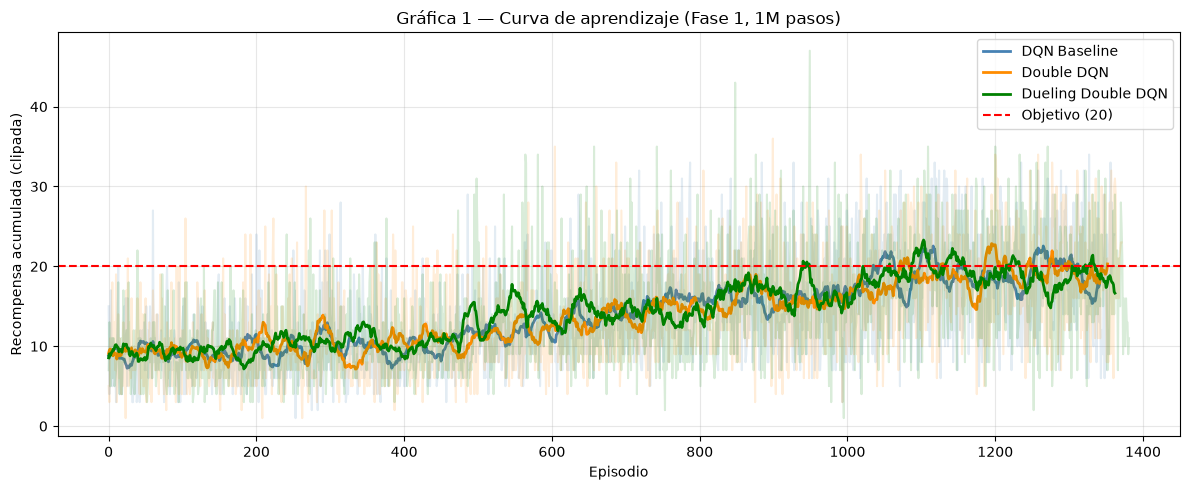

In [16]:
# Gráfica 1: Curva de aprendizaje (recompensa CLIPADA por episodio)
fig, ax = plt.subplots(figsize=(12, 5))
for rewards, label, color in [
    (reward_b, 'DQN Baseline',       'steelblue'),
    (reward_d, 'Double DQN',          'darkorange'),
    (reward_u, 'Dueling Double DQN',  'green'),
]:
    ax.plot(rewards, alpha=0.15, color=color)
    ax.plot(smooth(rewards), label=label, color=color, linewidth=2)

ax.axhline(y=20, color='red', linestyle='--', linewidth=1.5, label='Objetivo (20)')
ax.set_xlabel('Episodio')
ax.set_ylabel('Recompensa acumulada (clipada)')
ax.set_title('Gráfica 1 — Curva de aprendizaje (Fase 1, 1M pasos)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafica1_curva_aprendizaje.png', dpi=150)
plt.show()

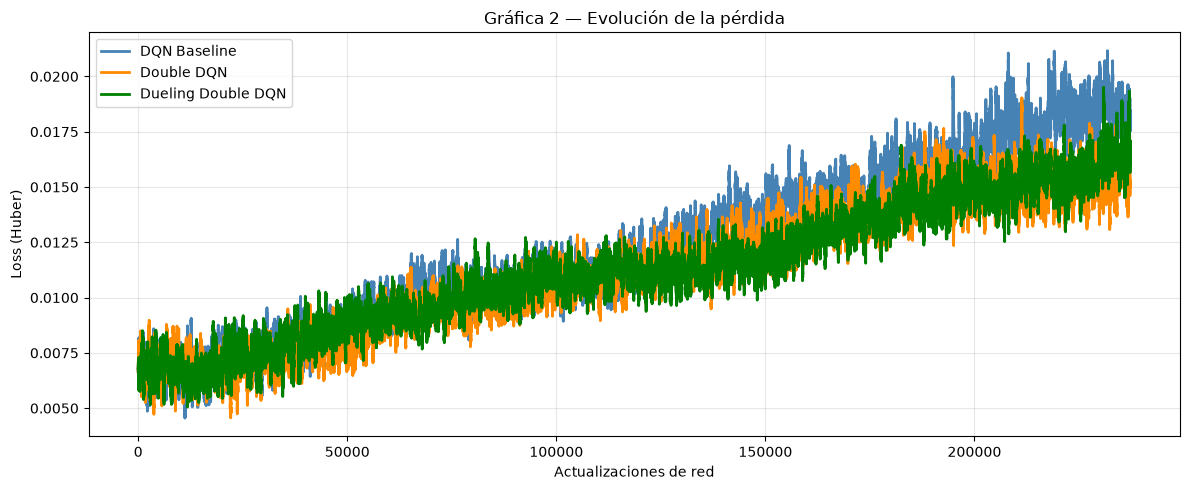

In [17]:
# Gráfica 2: Evolución de la pérdida
fig, ax = plt.subplots(figsize=(12, 5))
for loss, label, color in [
    (loss_b, 'DQN Baseline',       'steelblue'),
    (loss_d, 'Double DQN',          'darkorange'),
    (loss_u, 'Dueling Double DQN',  'green'),
]:
    if loss:
        ax.plot(smooth(loss, window=200), label=label, color=color, linewidth=2)

ax.set_xlabel('Actualizaciones de red')
ax.set_ylabel('Loss (Huber)')
ax.set_title('Gráfica 2 — Evolución de la pérdida')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafica2_loss.png', dpi=150)
plt.show()

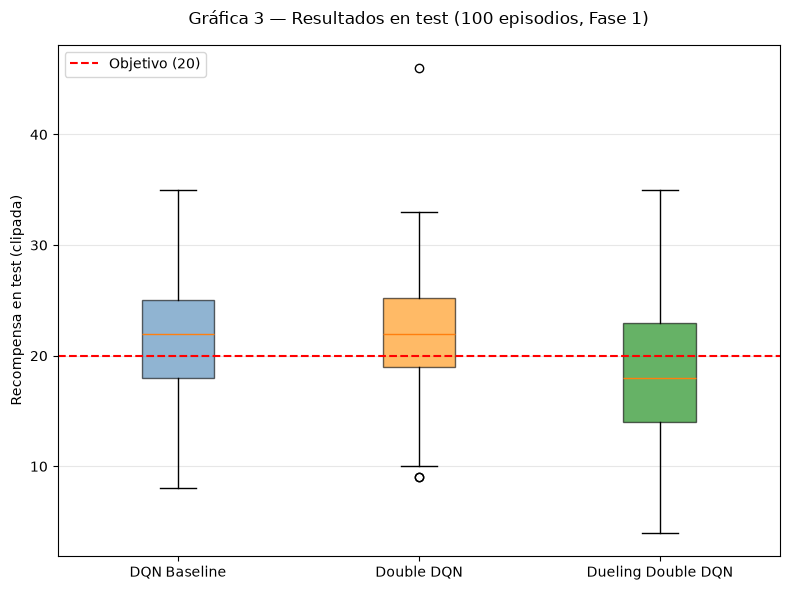

In [ ]:
test_rewards_baseline = json.load(open('results_baseline_pipe.json'))['test_rewards']
test_rewards_double   = json.load(open('results_double_pipe.json'))['test_rewards']
test_rewards_dueling  = json.load(open('results_dueling_pipe.json'))['test_rewards']

# Gráfica 3: Resultados en test (100 episodios, fase 1)
fig, ax = plt.subplots(figsize=(8, 6))

bp = ax.boxplot(
    [test_rewards_baseline, test_rewards_double, test_rewards_dueling],
    patch_artist=True
)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['DQN Baseline', 'Double DQN', 'Dueling Double DQN'], fontsize=10)

for patch, color in zip(bp['boxes'], ['steelblue', 'darkorange', 'green']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Línea de objetivo y etiquetas
ax.axhline(y=20, color='red', linestyle='--', label='Objetivo (20)')
ax.set_ylabel('Recompensa en test (clipada)')
ax.set_title('Gráfica 3 — Resultados en test (100 episodios, Fase 1)', fontsize=12, pad=15)

ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('grafica3_test_boxplot.png', dpi=150)
plt.show()

/home/paulacaro/miniconda3/envs/tfm_gnn/lib/python3.11/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment SpaceInvaders-v0 is out of date. You should consider upgrading to version `v4`.
  logger.deprecation(



Media CLIPADA: 25.70 | Std: 5.17  (raw ref: 401)


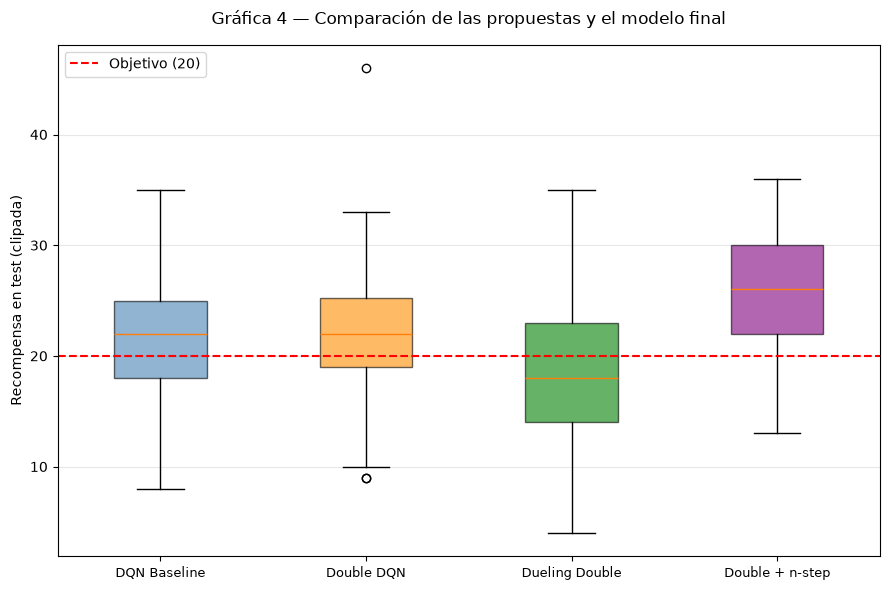

In [19]:
tb = json.load(open('results_baseline_pipe.json'))['test_rewards']
td = json.load(open('results_double_pipe.json'))['test_rewards']
tu = json.load(open('results_dueling_pipe.json'))['test_rewards']

# Gráfica 4: modelo final (Double + n-step): evaluación de 100 episodios
net_ns = NatureDQN(nb_actions).to(device)
net_ns.load_state_dict(torch.load('dqn_double_nstep_pipe.pt', map_location=device))
tn = list(test_agent(net_ns, nb_episodes=100, eps=0.0, verbose=False))

datos   = [tb, td, tu, tn]
labels  = ['DQN Baseline', 'Double DQN', 'Dueling Double', 'Double + n-step']
colores = ['steelblue', 'darkorange', 'green', 'purple']

fig, ax = plt.subplots(figsize=(9, 6))
bp = ax.boxplot(datos, patch_artist=True)
ax.set_xticks(range(1, len(labels) + 1)); ax.set_xticklabels(labels, fontsize=9)
for patch, c in zip(bp['boxes'], colores):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.axhline(y=20, color='red', linestyle='--', label='Objetivo (20)')
ax.set_ylabel('Recompensa en test (clipada)')
ax.set_title('Gráfica 4 — Comparación de las propuestas y el modelo final', pad=15)
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig('grafica4_boxplot_final.png', dpi=150); plt.show()

---
### 2.15. Justificación de parámetros y resultados


#### 2.15.1. Arquitectura de la red neuronal

Se usa una CNN en lugar de una red densa porque estamos trabajando con imágenes  como entrada (84×84 píxeles × 4 frames apilados). Las CNNs extraen características espaciales locales, como bordes, formas, posición y movimiento de objetos, de forma eficiente. Una red densa trataría cada píxel de forma independiente, ignorando la estructura espacial y multiplicando el número de parámetros de forma inviable.

La arquitectura sigue el diseño de Mnih et al. (2015), con tres capas convolucionales en cascada:

- **Conv1 (32 filtros, 8×8, stride 4)**: captura estructuras de gran escala; reduce el mapa espacial de 84×84 a 20×20.
- **Conv2 (64 filtros, 4×4, stride 2)**: detecta patrones más locales; reduce a 9×9.
- **Conv3 (64 filtros, 3×3, stride 1)**: extrae características finas sin reducción espacial; produce 64×7×7 = 3136 activaciones.
- **FC (3136 → 512 → nb_actions)**: integra las características en un Q-value por acción.

La diferencia entre `NatureDQN` y `DuelingDQN` está en la cabeza. En `NatureDQN`, las capas `FC` producen directamente `Q(s,a)` para cada acción. En `DuelingDQN`, la cabeza se divide en dos *streams* paralelos: uno estima `V(s)` (el valor del estado, independiente de la acción) y otro estima `A(s,a)` (la ventaja relativa de cada acción). La combinación `Q(s,a) = V(s) + A(s,a) − mean(A(s,·))` permite que la red aprenda cuándo un estado es valioso, sin importar qué acción se elija. Esto es especialmente útil en *SpaceInvaders*, donde muchos frames no requieren ninguna acción específica (el agente puede simplemente moverse sin disparar).

#### 2.15.2. Hiperparámetros seleccionados

La mayoría de valores siguen a Mnih et al. (2015). Como parte del **pipeline estable** se ajustaron tres:

- **`LEARNING_RATE` = 1e-4** (en lugar de 2.5e-4). Con Adam, la tasa del paper resultaba demasiado alta al alargar el entrenamiento y provocaba inestabilidad y olvido. Cuando probabamos a escalar a más pasos hundía el rendimiento, mientras que una tasa más baja hacía el entrenamiento más estable.
- **`MEMORY_LIMIT` = 150.000**. Reducido respecto a los 200.000 iniciales por la RAM disponible; mantiene diversidad suficiente de experiencias.
- **`EPS_MIN` = 0.05** junto con **evaluación periódica** (`EVAL_EVERY`) que guarda el mejor modelo. El *checkpointing por evaluación* garantiza quedarnos con el pico de rendimiento aunque el entrenamiento posterior se degrade.

El resto (`GAMMA`, `TARGET_UPDATE`, `TRAIN_INTERVAL`, `BATCH_SIZE`, warmup) se mantienen.

Al escalar el entrenamiento, hemos ajustado la exploración reduciendo `EPS_MIN` de 0.1 a 0.05, y en las fases de reanudación fijando $\epsilon = 0.02$ constante. Ya que, con la política ya formada, tanta exploración mete ruido, y bajarla acerca el comportamiento de entrenaminto a la política greedy de evaluación y estabiliza la mejora sin reiniciar la exploración desde 1.0.

#### 2.15.3. Análisis de las propuestas


**Fase 1 — comparación a 1M pasos (mismo pipeline).**

- DQN Baseline: media test 21.77 (std 5.50).
- Double DQN: media test 22.18 (std 5.97).
- Dueling Double DQN: media test 18.41 (std 6.28).

A igual presupuesto, la mejor arquitectura es **Double DQN**, seguida muy de cerca por Baseline (la diferencia entre ambas está dentro de la variabilidad, std $\approx$ 6). Double DQN reduce la sobreestimación de Q-values al desacoplar la selección y la evaluación de la acción, lo que se traduce en decisiones más consistentes. La Dueling Double DQN queda por debajo (18.41): su cabeza dividida en *streams* V(s) y A(s,a) añade parámetros que necesitan más muestras para estabilizarse, y con solo 1M de pasos no llega a aprovechar su ventaja frente a una cabeza más simple.

**Fase 2 — escalar la ganadora (Double DQN) a 3M pasos.**

Reanudando desde el modelo de 1M (no desde cero) y con exploración decreciente, la media de test sube a **25.44 > 20**, consolidando el margen sobre el objetivo.

**Fase 2.1 — mejora adicional con n-step returns.**

Sobre el mejor Double DQN aplicamos retornos *n*-step (n = 3). El efecto es doble: la media sube a **27.02** y la varianza baja (std 5.81 → 5.02), reduciendo la proporción de episodios por debajo de 20. Es la mejor propuesta y el modelo final.

**Hallazgo (resultado negativo):** Escalar pasos "a lo bruto" con la configuración inicial (LR alto, buffer pequeño, exploración muy baja) degradaba el modelo: en pruebas previas la media caía de $\approx$ 19 a $\approx$ 13 al pasar de 3M a 5M. La mejora vino del **pipeline de preprocesado + entrenamiento estable + checkpointing por evaluación + n-step**, no de añadir pasos sin más.

**Sobre el objetivo ideal (mínimo ≥ 20 en 100 episodios consecutivos).** No se alcanza de forma estable: sobre 80 tandas de 100 episodios del modelo final la media es $\approx$ 26 y, de media, $\approx$ 87% de los episodios superan 20 (en la mejor tanda, 96/100). Ese $\approx$ 13% por debajo es intrínseco a SpaceInvaders-v0: las *sticky actions* (prob. 0.25) y los patrones aleatorios de disparo provocan muertes tempranas ocasionales, y ninguna variante estándar de DQN lo elimina.

#### 2.15.4. Conclusiones

El modelo seleccionado para la entrega es **Double DQN con n-step returns** (`dqn_double_nstep_pipe.pt`), con media de test (clipada) **27.02** sobre 100 episodios y $\approx$ 87% de episodios $\geq$ 20 sobre 80 evaluaciones. Las claves de la mejora frente a la primera entrega fueron: 
1. forzar el reward clipping en la evaluación
2. el preprocesado estándar de Atari (frame-max, noop-reset, episodic-life)
3. un entrenamiento estable (LR más bajo, menos exploración al escalar pasos y *checkpointing* por evaluación) tras comprobar que escalar pasos sin más degradaba el modelo
4. los retornos n-step, que subieron la media y redujeron la varianza. La variabilidad entre episodios (std $\approx$ 5) es propia del entorno; el criterio ideal de mínimo $\geq$ 20 no se alcanza de forma fiable por la estocasticidad de v0, como se detalla arriba.

---
## **Grabación de vídeo del agente**



In [30]:
import glob, io, base64
from IPython.display import HTML

best_net = NatureDQN(nb_actions).to(device)
best_net.load_state_dict(torch.load('dqn_double_nstep_pipe.pt', map_location=device))   # <-- mejor modelo (Double + n-step)
best_net.eval()

video_dir = os.path.join(os.getcwd(), 'video_agent')
os.makedirs(video_dir, exist_ok=True)

env_video = gym.make(env_name, render_mode='rgb_array')
env_video = gym.wrappers.RecordVideo(env_video, video_dir, episode_trigger=lambda e: True)

processor_v   = AtariProcessor()
frame_stack_v = FrameStack(WINDOW_LENGTH)
_last2 = deque(maxlen=2)
def _maxframe_v(raw):                                  # mismo frame-max que en entrenamiento
    f = processor_v.process_observation(raw); _last2.append(f)
    return np.max(np.stack(list(_last2)), axis=0).astype(np.uint8)

obs, _ = env_video.reset()
_last2.clear()
state = frame_stack_v.reset(_maxframe_v(obs))
done, total_reward, total_clip = False, 0, 0.0

while not done:
    with torch.no_grad():
        s = torch.FloatTensor(state).unsqueeze(0).to(device) / 255.0
        action = best_net(s).argmax().item()
    obs, reward, terminated, truncated, _ = env_video.step(action)
    done = terminated or truncated
    total_reward += reward; total_clip += float(np.clip(reward, -1, 1))
    state = frame_stack_v.step(_maxframe_v(obs))

env_video.close()
print(f'Recompensa del episodio grabado -> raw: {total_reward} | clipada: {total_clip:.0f}')

/home/paulacaro/miniconda3/envs/tfm_gnn/lib/python3.11/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment SpaceInvaders-v0 is out of date. You should consider upgrading to version `v4`.
  logger.deprecation(
/home/paulacaro/miniconda3/envs/tfm_gnn/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/paulacaro/08 Aprendizaje Por Refuerzo/04_PROYECTO/video_agent folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Recompensa del episodio grabado -> raw: 490.0 | clipada: 30


---
## **Referencias**

- Farama Foundation. (2023). *SpaceInvaders* [Documentación del entorno]. 
Arcade Learning Environment. https://ale.farama.org/environments/space_invaders/

- Mnih, V., Kavukcuoglu, K., Silver, D., Rusu, A. A., Veness, J., Bellemare, M. G., Graves, A., Riedmiller, M., Fidjeland, A. K., Ostrovski, G., Petersen, S., Beattie, C., Sadik, A., Antonoglou, I., King, H., Kumaran, D., Wierstra, D., Legg, S., & Hassabis, D. (2015). Human-level control through deep reinforcement learning. *Nature*, *518*, 529–533. https://doi.org/10.1038/nature14236

- van Hasselt, H., Guez, A., & Silver, D. (2016). Deep reinforcement learning with double Q-learning. *Proceedings of the 30th AAAI Conference on Artificial Intelligence (AAAI-16)*, 2094–2100. https://arxiv.org/abs/1509.06461

- Wang, Z., Schaul, T., Hessel, M., van Hasselt, H., Lanctot, M., & de Freitas, N. (2016). Dueling network architectures for deep reinforcement learning. *Proceedings of the 33rd International Conference on Machine Learning (ICML-16)*, 1995–2003. https://arxiv.org/abs/1511.07401

- Hessel, M., Modayil, J., van Hasselt, H., Schaul, T., Ostrovski, G., Dabney, W., Horgan, D., Piot, B., Azar, M., & Silver, D. (2018). *Rainbow: Combining improvements in deep reinforcement learning.* Proceedings of the 32nd AAAI Conference on Artificial Intelligence (AAAI-18), 3215–3222. https://arxiv.org/abs/1710.02298

---

## **Declaración de uso de inteligencia artificial**

En la elaboración de este trabajo se ha utilizado el modelo de lenguaje **Claude** (Anthropic, 2026) como herramienta de apoyo para la corrección de errores de código y la mejora de la redacción de textos explicativos. El diseño experimental, la interpretación de resultados y las conclusiones son propias.

Anthropic. (2026). *Claude* (claude-sonnet-4-6) [Modelo de lenguaje de gran escala]. https://www.anthropic.com